# Assignment 2 - Xiaole Zuo

## question 1

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import random
import math


# Step 1: dealing the information with movies data into a new list
# Loading the Movies Data
def load_data_movies(file_path):
    # step 1: Initialize an empty list to store the processed movie data
    data = []
    # step 2: Open the file with 'latin-1' encoding
    with open(file_path, 'r', encoding='latin-1') as file:
        # step 3: Read each line in the file one by one
        for line in file:
            # step 4: Remove the newline character at the end of each line
            line = line.strip('\n')
            # step 5: Split the line into parts using '::' as the delimiter(as readme file said)
            line = line.split('::')
            # step 6: Split the genres string into individual genres using '|' as a delimiter(as readme file said)
            genres = line[2].split('|')
            # step 7: Initialize an empty list to store the integer odes for each genre
            genres_int = []
            # step 8: Iterate over each genre in the list of genres. Each genre is uniquely identified by an integer form 0 to 1
            for genre in genres:
                if genre == 'Action':
                    genres_int.append(0)
                if genre == 'Adventure':
                    genres_int.append(1)
                if genre == 'Animation':
                    genres_int.append(2)
                if genre == "Children's":
                    genres_int.append(3)
                if genre == 'Comedy':
                    genres_int.append(4)
                if genre == 'Crime':
                    genres_int.append(5)
                if genre == 'Documentary':
                    genres_int.append(6)
                if genre == 'Drama':
                    genres_int.append(7)
                if genre == 'Fantasy':
                    genres_int.append(8)
                if genre == 'Film-Noir':
                    genres_int.append(9)
                if genre == 'Horror':
                    genres_int.append(10)
                if genre == 'Musical':
                    genres_int.append(11)
                if genre == 'Mystery':
                    genres_int.append(12)
                if genre == 'Romance':
                    genres_int.append(13)
                if genre == 'Sci-Fi':
                    genres_int.append(14)
                if genre == 'Thriller':
                    genres_int.append(15)
                if genre == 'War':
                    genres_int.append(16)
                if genre == 'Western':
                    genres_int.append(17)
            # step 9: Replace the genres in the original line with their integer codes
            line[2] = genres_int
            # step 10: Append the modified line to the main data list
            data.append(line)
    return data


# Step 2: rating data
def load_data_ratings(file_path):
    data = []
    with open(file_path, 'r', encoding='latin-1') as file:
        for line in file:
            line = line.strip('\n')
            line = line.split('::')
            data.append(line)
    return data


# Step 3: combine movie ID with rating
def classification(data_movies, data_ratings):
    # step 1: Creat 18 empt lists for eacj genre
    data = []
    for i in range(18):
        data.append([])
    # step 2: Iterate over each movie in the movies data
    for movie in data_movies:
        # step 3: Iterate over each rating in the ratings data
        for rating_line in data_ratings:
            # step 4: Match movie ID in ratings:
            if int(movie[0]) == int(rating_line[1]):
                for genre in movie[2]:
                    data[genre].append(int(rating_line[2]))
    return data


# Step 4: Intializes UCB algorithm
class UpperConfidenceBound:
    def __init__(self, num_actions, horizon, B):
        self.num_actions = num_actions
        self.horizon = horizon
        self.B = B
        self.action_counts = np.zeros(num_actions)
        self.cumulative_rewards = np.zeros(num_actions)
        self.round = 0

    # Step 5: define UCB algorithm calculation and asymptotically optimal UCB algorithms
    def select_action(self, l):
        average_rewards = np.zeros(self.num_actions)
        for i in range(self.num_actions):
            if self.action_counts[i] == 0:
                average_rewards[i] = 5
            else:
                average_rewards[i] = self.cumulative_rewards[i] / self.action_counts[i] + math.sqrt(
                    l * math.log(self.horizon) / self.action_counts[i]) * self.B / 2
        action = np.argmax(average_rewards)
        self.round += 1
        return action
    
    def asymptotical_UCB_action(self, l):
        average_rewards = np.zeros(self.num_actions)
        for i in range(self.num_actions):
            if self.action_counts[i] == 0:
                average_rewards[i] = 5
            else:
                average_rewards[i] = self.cumulative_rewards[i] / self.action_counts[i] + math.sqrt(
                    l * math.log(1+(i+1)*math.pow(math.log(i+1), 2) / self.action_counts[i]) * self.B / 2)
        action = np.argmax(average_rewards)
        self.round += 1
        return action

    # Step 6: update results
    def update(self, action, reward):
        self.action_counts[action] += 1
        self.cumulative_rewards[action] += reward


# Step 7
def run_experiment(data, num_experiments, horizon, l):
    results = np.zeros((num_experiments, horizon))
    expect_rating = 0 
    for genre in data:
        if sum(genre) / len(genre) > expect_rating:
            expect_rating = sum(genre) / len(genre)
    B = 4 # rewards (i.e., ratings) can be in the interval 1-5 (stars),B should be set as 4 
    for exp in range(num_experiments):
        np.random.shuffle(data)
        num_actions = len(data)
        etc_algorithm = UpperConfidenceBound(num_actions, horizon, B)
        for t in range(horizon):
            selected_action = etc_algorithm.select_action(l)
            reward = data[selected_action][np.random.randint(0, len(data[selected_action]))]
            etc_algorithm.update(selected_action, reward)
            cumulative_regret = expect_rating * (t + 1) - np.sum(etc_algorithm.cumulative_rewards)
            results[exp, t] = cumulative_regret
    return results

def run_experiment_asymptotically(data, num_experiments, horizon, l):
    results = np.zeros((num_experiments, horizon))
    expect_rating = 0
    for genre in data:
        if sum(genre) / len(genre) > expect_rating:
            expect_rating = sum(genre) / len(genre)
    B = 4
    for exp in range(num_experiments):
        np.random.shuffle(data)
        num_actions = len(data)
        aUCB_algorithm = UpperConfidenceBound(num_actions, horizon, B)
        for t in range(horizon):
            selected_action = aUCB_algorithm.asymptotical_UCB_action(l)
            reward = data[selected_action][np.random.randint(0, len(data[selected_action]))]
            aUCB_algorithm.update(selected_action, reward)
            cumulative_regret = expect_rating * (t + 1) - np.sum(aUCB_algorithm.cumulative_rewards)
            results[exp, t] = cumulative_regret
    return results
                    
# input the data
if __name__ == "__main__":
    movie_path = "movies.dat"
    rating_path = "ratings.dat"
    data_movies = load_data_movies(movie_path)
    data_ratings = load_data_ratings(rating_path)
    data = classification(data_movies, data_ratings)

# question 1
num_experiments = 10
horizon = 100000
l = 4
regret_results = run_experiment(data, num_experiments, horizon, l)
plt.figure(figsize=(10, 6))
for exp in range(num_experiments):
    plt.plot(np.arange(1, horizon + 1), regret_results[exp, :], label=f'Experiment {exp + 1}')
plt.title('UCB Algorithm')
plt.xlabel('Round')
plt.ylabel('Regret')
plt.legend()
plt.show()

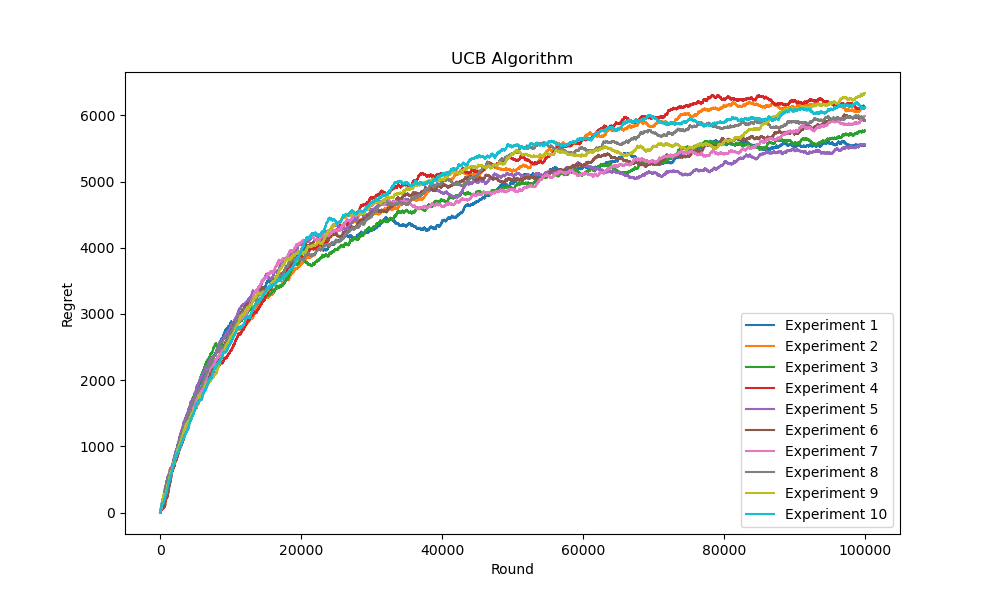

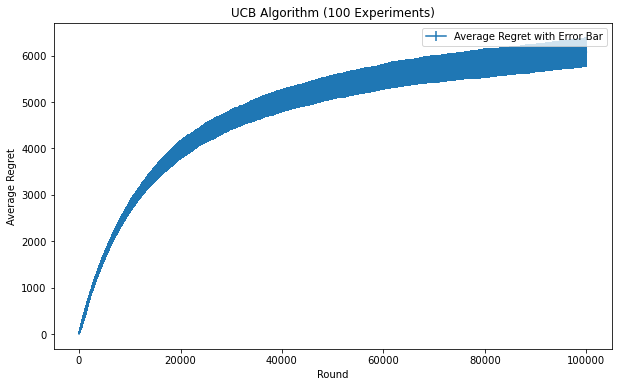

In [5]:
num_experiments = 100
horizon = 100000
l = 4
regret_results = run_experiment(data, num_experiments, horizon, l)
average_regret = np.mean(regret_results, axis=0)
std_dev_regret = np.std(regret_results, axis=0)

plt.figure(figsize = (10,6))
plt.errorbar(np.arange(1,horizon+1), average_regret, yerr=std_dev_regret, label = 'Average Regret with Error Bar')

plt.title('UCB Algorithm (100 Experiments)')
plt.xlabel('Round')
plt.ylabel('Average Regret')
plt.legend()
plt.show()

From the first picture, different experiments presented different curves, owing to picking random samples.

Therefore, the second picture showed the average regret with error bars. Error bars can mean that $ \sqrt{\frac{\ln{n}}{n}} $

## question 2

151.5937790920541


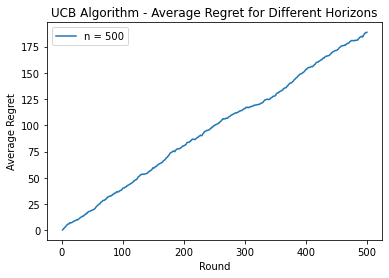

1542.9377909205432


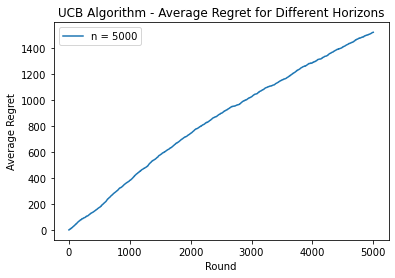

5062.377909205417


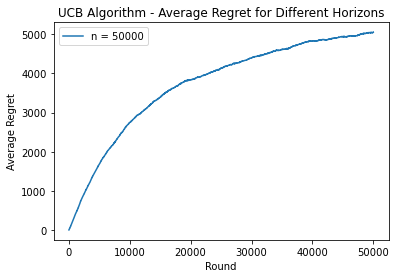

6466.779092054116


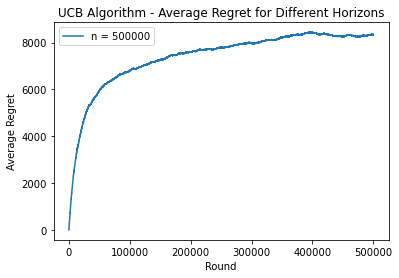

11251.79092054069


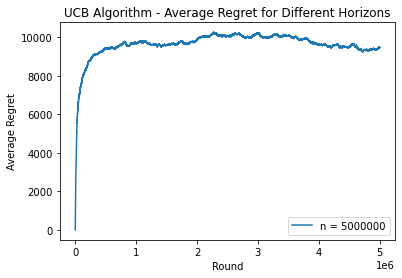

In [8]:
# question 2
num_experiments = 10
horizons = [500,5000,50000,500000, 5000000]
l = 4
for horizon in horizons:
    regret_results = run_experiment(data, num_experiments, horizon, l)
    print(regret_results[0][horizon-1])
    plt.plot(np.arange(1, horizon + 1), np.mean(regret_results, axis=0), label = f'n = {horizon}')
    plt.title('UCB Algorithm - Average Regret for Different Horizons')
    plt.xlabel('Round')
    plt.ylabel('Average Regret')
    plt.legend()
    plt.show()

P.S. Owing to too much time running the code with 100 experiments, the figures above were run with 10 experiments. However, I ran a picture with n=5000000 by 100 experiments in another software named pycharm, so I just presented the condition of n=5000000.
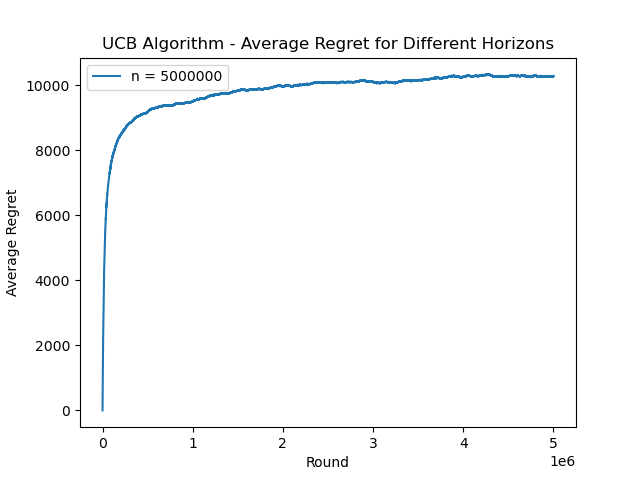

We can see that started by n=50000, the figure began to represent the logarithmic regret behavior. And compared the figure of n=5000000 by 10 experiments with 100 experiments, the latter presented more smoothly than another.


## question 3

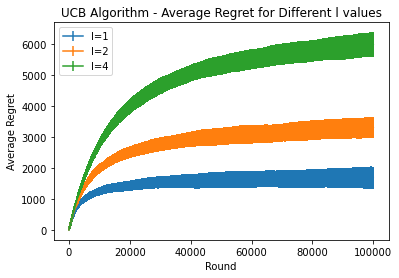

In [10]:
# question 3
num_experiments = 100
horizon = 100000
for l in[1, 2, 4]:
    regret_results = run_experiment(data, num_experiments, horizon, l)
    average_regret = np.mean(regret_results, axis=0)
    std_dev_regret = np.std(regret_results, axis=0)
    plt.errorbar(np.arange(1, horizon + 1), average_regret, yerr = std_dev_regret, label=f'l={l}')

plt.title('UCB Algorithm - Average Regret for Different l values')
plt.xlabel('Round')
plt.ylabel('Average Regret')
plt.legend()
plt.show()

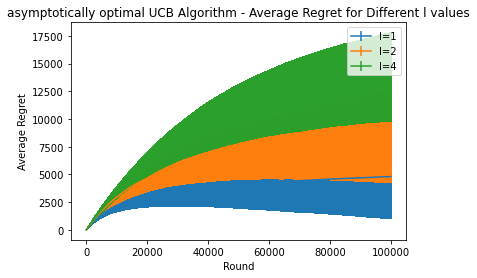

In [11]:
num_experiments = 100
horizon = 100000
for l in[1, 2, 4]:
    regret_results = run_experiment_asymptotically(data, num_experiments, horizon, l)
    average_regret = np.mean(regret_results, axis=0)
    std_dev_regret = np.std(regret_results, axis=0)
    plt.errorbar(np.arange(1, horizon + 1), average_regret, yerr = std_dev_regret, label=f'l={l}')

plt.title('asymptotically optimal UCB Algorithm - Average Regret for Different l values')
plt.xlabel('Round')
plt.ylabel('Average Regret')
plt.legend()
plt.show()

Above these two figures, we can see that whatever standard UCB or asymptotically optimal UCB, averages regrets and their own error bar would rise with the growth of l.

However, asymptotically optimal UCB Algorithm's error bar was much larger than standard one.

For asymptotically optimal UCB, $ error bar=2\sqrt{\frac{\ln{(1+t(\ln{t})^2)}}{n}} $

For standard one, $ error bar=2\sqrt{\frac{\ln{n}}{n}}$